## <span style="color:red">All imports and configuration live here</span>
#### Changing anything here WILL break stuff. It is discouraged unless you understand what's going on. Also, try not moving files or folders around.

In [1]:
%pip install -e "../..[mmd]"

Obtaining file:///Users/fuzi_x_muzi/Documents/PoliTech%20Research/Politech-Fair-Representation-Act
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for fair-representation-act (pyproject.toml) ... done
  Created wheel for fair-representation-act: filename=fair_representation_act-0.1.0-0.editable-py3-none-any.whl size=8466 sha256=0cba53a38663c4659c19a351f92ad35f1cc77cc085161ad411c3de20b796c85a
  Stored in directory: /private/var/folders/34/k7nfgbcn10qfj_089s0jtbs40000gn/T/pip-ephem-wheel-cache-p_0kk_qk/wheels/78/38/07/f50c7b1a22226fc8642bb0b1c5ebc328f7c45d8d16ff6e904a
Successfully built fair-representation-act
  Attempting uninstall: fair-representation-act
    Found existing installation: fair-representation-act 0.1.0
    Can't uninstall 'fair-representation-act'. No files were found to uninstall.

[notice] A 

In [2]:
import random
import json
import importlib
from MMD_Generation_Layer import config
import shutil
import os

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from functools import partial

from gerrychain import Graph, Partition, MarkovChain
from gerrychain.updaters import Tally
from gerrychain.tree import recursive_tree_part
from gerrychain.accept import always_accept
from gerrychain.proposals import recom
from gerrychain.constraints import within_percent_of_ideal_population, contiguous

from collections import defaultdict, deque
import sys

In [3]:
# Shared config import
importlib.reload(config)
from MMD_Generation_Layer.config import (
    processor_dir,
    base_dir,
    shape_path,
    output_dir,
    plans_dir,
    ensemble_csv_path,
    seat_share_png_path,
    NUM_PLANS,
    NUM_DISTRICTS,
    ID_COLUMN,
    GEOM_COLUMN,
    SEED
)

In [4]:
# !rm -rf output_dir

In [5]:
# Runtime mutable state
GDF = None

## <span style="color:red">Beginning of internal function definitions</span>
#### These functions are the heart of the redistricting algorithm. They currently rely on one shapefile for North Carolina to function. Future abstraction to various states is planned.

#### The <code>load_and_build_graph</code> function builds the graph that represents the voting districts. Each district is a node and each edge shows continuity.

In [6]:
def load_and_build_graph(shape_path=shape_path, id_col=ID_COLUMN, geom_col=GEOM_COLUMN):
    global GDF
    print("=" * 60)
    print("📊 STEP 1: Baseline Ensemble Generation")
    print("=" * 60)

    print("\n📂 Loading shapefile...")
    GDF = gpd.read_file(shape_path)
    print(f"✅ Loaded {len(GDF)} rows.")

    # Ensure geometry column is active
    if geom_col in GDF.columns:
        GDF = GDF.set_geometry(geom_col)

    # Required columns
    required_cols = {
        id_col,
        "TOTPOP",
        "G24PREDHAR",
        "G24PRERTRU",
        GDF.geometry.name
    }

    missing = required_cols - set(GDF.columns)
    if missing:
        raise KeyError(f"Missing required columns: {missing}")

    # Keep only what we need
    GDF = GDF[list(required_cols)].copy()

    # Normalize ID
    GDF[id_col] = GDF[id_col].astype(str).str.strip()

    if not GDF[id_col].is_unique:
        raise ValueError(f"{id_col} is not unique. Cannot use as node ID.")

    # Ensure numeric types
    GDF["TOTPOP"] = pd.to_numeric(GDF["TOTPOP"], errors="coerce").fillna(0).astype(int)
    GDF["G24PREDHAR"] = pd.to_numeric(GDF["G24PREDHAR"], errors="coerce").fillna(0).astype(int)
    GDF["G24PRERTRU"] = pd.to_numeric(GDF["G24PRERTRU"], errors="coerce").fillna(0).astype(int)

    # Fix invalid geometries
    invalid = ~GDF.geometry.is_valid
    if invalid.any():
        print(f"Repairing {invalid.sum()} invalid geometries...")
        GDF.loc[invalid, "geometry"] = GDF.loc[invalid, "geometry"].buffer(0)

    # Set index BEFORE building graph
    GDF = GDF.set_index(id_col, drop=False)

    print("\n🔨 Building GerryChain dual graph...")
    graph = Graph.from_geodataframe(GDF)

    # Attach attributes
    for node in graph.nodes():
        row = GDF.loc[node]
        graph.nodes[node]["population"] = row["TOTPOP"]
        graph.nodes[node]["votes_dem"] = row["G24PREDHAR"]
        graph.nodes[node]["votes_rep"] = row["G24PRERTRU"]

    # Graph diagnostics
    degrees = [graph.degree(n) for n in graph.nodes()]
    iso = sum(1 for d in degrees if d == 0)

    print(f"✅ Graph built ({len(graph.nodes())} nodes, {len(graph.edges())} edges)")
    print(f"   Isolated nodes: {iso}")
    print(f"   Degree min/median/max: "
          f"{min(degrees)}/{sorted(degrees)[len(degrees)//2]}/{max(degrees)}")

    return graph

#### The <code>create_initial_partition</code> function does some stuff I dont completely understand lmao

In [7]:
def create_initial_partition(graph, num_districts=NUM_DISTRICTS, seed=SEED):
    """
    Create initial contiguous partition using recursive tree partitioning.

    Args:
        graph: GerryChain Graph
        num_districts: Number of districts (default 14 for NC)
        seed: Random seed

    Returns:
        Partition object
    """
    random.seed(seed)

    print(f"\n🎲 Creating initial partition ({num_districts} districts)...")

    total_population = sum(graph.nodes[n]["population"] for n in graph.nodes())
    ideal_population = total_population / num_districts

    print(f"   Ideal population per district: {ideal_population:,.0f}")
    print(f"   Using recursive tree partitioning...")

    # Create contiguous initial partition
    assignment = recursive_tree_part(
        graph,
        range(num_districts),
        ideal_population,
        "population",
        0.05,  # 5% tolerance
        1
    )

    # Create partition with updaters
    partition = Partition(
        graph,
        assignment=assignment,
        updaters={
            "population": Tally("population"),
            "votes_dem": Tally("votes_dem"),
            "votes_rep": Tally("votes_rep"),
        }
    )

    print(f"✅ Initial partition created with {len(partition.parts)} districts.")

    return partition

#### Builds an ensemble of <code>NUM_DISTRICTS</code> different district plans

In [8]:
def generate_baseline_ensemble(graph, num_plans=NUM_PLANS, num_districts=NUM_DISTRICTS, seed=42):
    """
    Generate ensemble of random district plans using ReCom.

    Args:
        graph: GerryChain Graph
        num_plans: Number of plans to generate
        num_districts: Number of districts
        seed: Random seed

    Returns:
        List of (partition, results_dict) tuples
    """
    print(f"\n⚙️  Setting up ReCom chain to generate {num_plans} plans...")

    # Create initial partition
    initial_partition = create_initial_partition(graph, num_districts, seed)

    # Set up constraints
    population_constraint = within_percent_of_ideal_population(initial_partition, 0.05)

    # Set up ReCom proposal
    total_population = sum(graph.nodes[n]["population"] for n in graph.nodes())
    ideal_pop = total_population / num_districts

    proposal = partial(
        recom,
        pop_col="population",
        pop_target=ideal_pop,
        epsilon=0.05,
        node_repeats=2
    )

    # Create Markov chain
    chain = MarkovChain(
        proposal=proposal,
        constraints=[contiguous, population_constraint],
        accept=always_accept,
        initial_state=initial_partition,
        total_steps=num_plans
    )

    # Generate plans
    print(f"\n🚀 Generating {num_plans} random district plans...")
    print("   (This may take a minute...)")

    ensemble = []
    plan_counter = 0

    for partition in chain:
        plan_counter += 1

        # Calculate election results for this plan
        dem_seats = 0
        rep_seats = 0

        for district in partition.parts:
            district_dem = partition["votes_dem"][district]
            district_rep = partition["votes_rep"][district]

            if district_dem > district_rep:
                dem_seats += 1
            else:
                rep_seats += 1

        dem_seat_share = dem_seats / num_districts

        results = {
            "plan_id": plan_counter,
            "dem_seats": dem_seats,
            "rep_seats": rep_seats,
            "dem_seat_share": dem_seat_share
        }

        # Store partition assignment for visualization
        assignment = dict(partition.assignment)

        ensemble.append({
            "results": results,
            "assignment": assignment
        })

        if plan_counter % 5 == 0 or plan_counter == num_plans:
            print(f"   ✓ Generated {plan_counter}/{num_plans} plans...")

    print(f"✅ Generated {num_plans} random district plans.")

    return ensemble

#### <code>save_results</code> writes plan results to <code>outputs</code> directory.

In [9]:
def save_results(ensemble, output_dir):
    """
    Save ensemble results to CSV, histogram, and plan assignments.

    Args:
        ensemble: List of plan dictionaries
        output_dir: Output directory path
    """
    output_dir.mkdir(parents=True, exist_ok=True)

    print(f"\n💾 Saving results to {output_dir}...")

    # Save CSV with summary results
    results_df = pd.DataFrame([plan["results"] for plan in ensemble])
    results_df.to_csv(ensemble_csv_path, index=False)
    print(f"   ✓ Saved summary CSV: {ensemble_csv_path}")

    # Save plan assignments for dashboard
    plans_dir.mkdir(exist_ok=True)

    for plan in ensemble:
        plan_id = plan["results"]["plan_id"]
        assignment = plan["assignment"]

        assignment_path = plans_dir / f"plan_{plan_id}.json"
        with open(assignment_path, 'w') as f:
            # Convert keys to strings for JSON
            json_assignment = {str(k): int(v) for k, v in assignment.items()}
            json.dump(json_assignment, f)

    print(f"   ✓ Saved {len(ensemble)} plan assignments to {plans_dir}")
    
    # Generate histogram
    print("\n📈 Generating histogram...")
    plt.figure(figsize=(10, 6))
    plt.hist(results_df["dem_seat_share"], bins=10, edgecolor='black', alpha=0.7, color='steelblue')
    plt.xlabel("Democratic Seat Share", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.title(f"Baseline Ensemble: Democratic Seat Share Distribution\n({NUM_PLANS} Random District Plans)", fontsize=14, fontweight='bold')
    plt.axvline(results_df["dem_seat_share"].mean(), color='red', linestyle='--',
                linewidth=2, label=f"Mean: {results_df['dem_seat_share'].mean():.3f}")
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.savefig(seat_share_png_path, dpi=150, bbox_inches='tight')
    print(f"   ✓ Saved histogram: {seat_share_png_path}")

    # Print summary statistics
    print(f"\n📊 Summary Statistics:")
    print(f"   Mean Democratic seat share: {results_df['dem_seat_share'].mean():.3f}")
    print(f"   Std Dev: {results_df['dem_seat_share'].std():.3f}")
    print(f"   Min: {results_df['dem_seat_share'].min():.3f}")
    print(f"   Max: {results_df['dem_seat_share'].max():.3f}")

    print("\n✅ Election simulation complete — results saved.")

#### <code>generate_district_csvs</code> produces the csv output files for each district plan.

In [10]:
def generate_district_csvs():
    """Generate district-level CSV files for all plans."""

    global GDF
    print("=" * 60)
    print("📊 GENERATING DISTRICT-LEVEL CSV FILES")
    print("=" * 60)

    # Get list of plan files
    plan_files = sorted(plans_dir.glob("plan_*.json"))
    print(f"\n🗂️  Found {len(plan_files)} plan assignment files")

    # Process each plan
    for plan_file in plan_files:
        plan_id = int(plan_file.stem.split('_')[1])

        print(f"\n   Processing Plan {plan_id}...")

        # Load assignment
        with open(plan_file, 'r') as f:
            assignment = json.load(f)

        # Convert keys to integers
        assignment = {str(k): v for k, v in assignment.items()}

        # Create district-level aggregates
        district_results = []

        # Get unique districts
        districts = sorted(set(assignment.values()))

        for district_id in districts:
            # Get precincts in this district
            precinct_ids = [k for k, v in assignment.items() if v == district_id]

            # Filter geodataframe to these precincts
            district_precincts = GDF[GDF.index.isin(precinct_ids)]

            # Aggregate votes and population
            dem_votes = district_precincts['G24PREDHAR'].sum()
            rep_votes = district_precincts['G24PRERTRU'].sum()
            population = district_precincts['TOTPOP'].sum()

            # Determine winner
            winner = 'Democrat' if dem_votes > rep_votes else 'Republican'

            district_results.append({
                'plan_id': plan_id,
                'district_id': district_id,
                'dem_votes': int(dem_votes),
                'rep_votes': int(rep_votes),
                'population': int(population),
                'winner': winner
            })

        # Create DataFrame and save
        district_df = pd.DataFrame(district_results)
        output_path = output_dir / f"baseline_districts_plan_{plan_id}.csv"
        district_df.to_csv(output_path, index=False)

        print(f"      ✓ Saved {len(district_df)} districts to {output_path.name}")

    print("\n" + "=" * 60)
    print("✅ All district-level CSV files generated")
    print("=" * 60)

    return True

#### <code>plot_baseline_histogram</code> creates the histogram that shows the number of seats won by democrats across the plans

In [11]:
"""
Plot Baseline Results

Reads baseline_ensemble.csv and creates a histogram of Democratic seat counts.
Saves output as democratic_seats.png
"""
def plot_baseline_histogram(csv_path, output_dir):
    """
    Create histogram of Democratic seat distribution from baseline ensemble.

    Args:
        csv_path: Path to baseline_ensemble.csv
        output_dir: Directory to save histogram PNG

    Returns:
        True if successful, False otherwise
    """

    print("=" * 60)
    print("📈 BASELINE RESULTS VISUALIZATION")
    print("=" * 60)

    # Check if CSV exists
    if not Path(csv_path).exists():
        print(f"\n❌ ERROR: Results file not found at {csv_path}")
        print("   Please run 'python scripts/run_baseline_simple.py' first")
        return False

    # Load data
    print(f"\n📂 Loading results from: {csv_path}")
    try:
        df = pd.read_csv(csv_path)
        print(f"✅ Loaded {len(df)} plans")
    except Exception as e:
        print(f"❌ ERROR loading CSV: {e}")
        return False

    # Validate data
    required_cols = ['plan_id', 'dem_seats', 'rep_seats']
    if not all(col in df.columns for col in required_cols):
        print(f"❌ ERROR: CSV missing required columns: {required_cols}")
        return False

    # Summary statistics
    print(f"\n📊 Summary Statistics:")
    print(f"   Number of plans: {len(df)}")
    print(f"   Democratic seats:")
    print(f"      Mean:   {df['dem_seats'].mean():.2f}")
    print(f"      Median: {df['dem_seats'].median():.0f}")
    print(f"      Min:    {df['dem_seats'].min()}")
    print(f"      Max:    {df['dem_seats'].max()}")
    print(f"      Std:    {df['dem_seats'].std():.2f}")

    # Create histogram
    print(f"\n🎨 Creating histogram...")

    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot histogram
    ax.hist(df['dem_seats'], bins=range(df['dem_seats'].min(), df['dem_seats'].max() + 2),
            edgecolor='black', alpha=0.7, color='steelblue', align='left')

    # Add mean line
    mean_seats = df['dem_seats'].mean()
    ax.axvline(mean_seats, color='red', linestyle='--',
               linewidth=2, label=f'Mean: {mean_seats:.2f}')

    # Styling
    ax.set_xlabel(f'Democratic Seats (out of {NUM_DISTRICTS})', fontsize=12, fontweight='bold')
    ax.set_ylabel('Frequency (Number of Plans)', fontsize=12, fontweight='bold')
    ax.set_title(f'Baseline Ensemble: Democratic Seat Distribution\n({NUM_PLANS} Random Single-Member District Plans)',
                 fontsize=14, fontweight='bold', pad=20)

    # Set x-axis to show all possible seat counts
    ax.set_xticks(range(0, 15))
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(fontsize=11, loc='upper right')

    plt.tight_layout()

    # Save figure
    output_path = output_dir / "democratic_seats.png"
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    print(f"✅ Saved histogram to: {output_path}")

    # Also show vote share info
    if 'dem_seat_share' in df.columns:
        print(f"\n🗳️  Democratic Seat Share:")
        print(f"   Mean:   {df['dem_seat_share'].mean():.3f} ({df['dem_seat_share'].mean()*100:.1f}%)")
        print(f"   Min:    {df['dem_seat_share'].min():.3f} ({df['dem_seat_share'].min()*100:.1f}%)")
        print(f"   Max:    {df['dem_seat_share'].max():.3f} ({df['dem_seat_share'].max()*100:.1f}%)")

    print("\n" + "=" * 60)
    print("✅ Visualization complete")
    print("=" * 60)

## <span style="color:red">Beginning of function execution</span>
#### Here is where the above functions are exectued. Observe the output below each function to get a glimpse of what they're doing internally. Any errors in execution will be listed below the failed function and execution will halt.

In [12]:
graph = load_and_build_graph(str(shape_path), ID_COLUMN)

📊 STEP 1: Baseline Ensemble Generation

📂 Loading shapefile...
✅ Loaded 2658 rows.

🔨 Building GerryChain dual graph...
✅ Graph built (2658 nodes, 7504 edges)
   Isolated nodes: 0
   Degree min/median/max: 1/6/16


In [13]:
ensemble = generate_baseline_ensemble(graph, NUM_PLANS, NUM_DISTRICTS, SEED)


⚙️  Setting up ReCom chain to generate 100 plans...

🎲 Creating initial partition (14 districts)...
   Ideal population per district: 762,804
   Using recursive tree partitioning...
✅ Initial partition created with 14 districts.

🚀 Generating 100 random district plans...
   (This may take a minute...)
   ✓ Generated 5/100 plans...
   ✓ Generated 10/100 plans...
   ✓ Generated 15/100 plans...
   ✓ Generated 20/100 plans...
   ✓ Generated 25/100 plans...
   ✓ Generated 30/100 plans...
   ✓ Generated 35/100 plans...
   ✓ Generated 40/100 plans...
   ✓ Generated 45/100 plans...
   ✓ Generated 50/100 plans...
   ✓ Generated 55/100 plans...
   ✓ Generated 60/100 plans...
   ✓ Generated 65/100 plans...
   ✓ Generated 70/100 plans...
   ✓ Generated 75/100 plans...
   ✓ Generated 80/100 plans...
   ✓ Generated 85/100 plans...
   ✓ Generated 90/100 plans...
   ✓ Generated 95/100 plans...
   ✓ Generated 100/100 plans...
✅ Generated 100 random district plans.



💾 Saving results to /Users/fuzi_x_muzi/Documents/PoliTech Research/Politech-Fair-Representation-Act/MMD_Generation_Layer/Outputs...
   ✓ Saved summary CSV: /Users/fuzi_x_muzi/Documents/PoliTech Research/Politech-Fair-Representation-Act/MMD_Generation_Layer/Outputs/baseline_ensemble.csv
   ✓ Saved 100 plan assignments to /Users/fuzi_x_muzi/Documents/PoliTech Research/Politech-Fair-Representation-Act/MMD_Generation_Layer/Outputs/Plan_Assignments

📈 Generating histogram...
   ✓ Saved histogram: /Users/fuzi_x_muzi/Documents/PoliTech Research/Politech-Fair-Representation-Act/MMD_Generation_Layer/Outputs/seat_share.png

📊 Summary Statistics:
   Mean Democratic seat share: 0.434
   Std Dev: 0.041
   Min: 0.357
   Max: 0.500

✅ Election simulation complete — results saved.


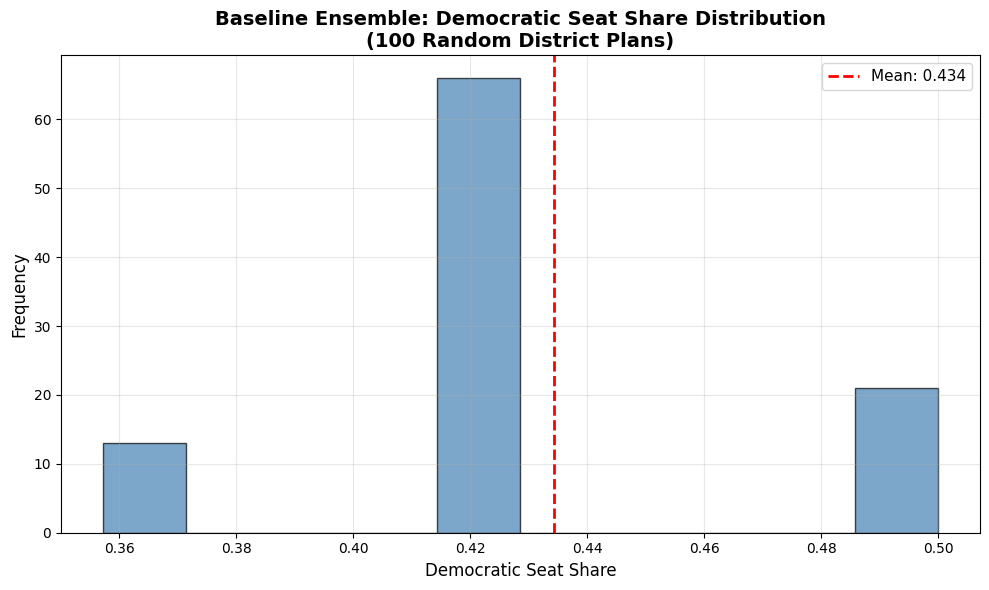

In [14]:
save_results(ensemble, output_dir)

#### Deprecated district contiguity check

In [15]:
# # Check contiguity per district (graph-based)
# def load_plan_assignment(plan_id, plans_dir):
#     """Load district assignment for a specific plan."""
#     assignment_path = plans_dir / f"plan_{plan_id}.json"
# 
#     if not assignment_path.exists():
#         return None
# 
#     with open(assignment_path, 'r') as f:
#         assignment = json.load(f)
# 
#     return assignment
#
# PLAN_ID = 40
# assignment = load_plan_assignment(PLAN_ID, plans_dir)
# if not assignment:
#     print(f"Could not load assignment for Plan {PLAN_ID}")
#     sys.exit(1)
#     
# district_nodes = defaultdict(list)
# for n, d in assignment.items():
#     district_nodes[d].append(n)
# 
# def is_connected(nodes):
#     nodes = set(nodes)
#     start = next(iter(nodes))
#     q = deque([start])
#     seen = {start}
#     while q:
#         u = q.popleft()
#         for v in graph.neighbors(u):
#             if v in nodes and v not in seen:
#                 seen.add(v)
#                 q.append(v)
#     return len(seen) == len(nodes)
# 
# bad = [d for d, nodes in district_nodes.items() if not is_connected(nodes)]
# print("Non-contiguous districts:", bad)

📈 BASELINE RESULTS VISUALIZATION

📂 Loading results from: /Users/fuzi_x_muzi/Documents/PoliTech Research/Politech-Fair-Representation-Act/MMD_Generation_Layer/Outputs/baseline_ensemble.csv
✅ Loaded 100 plans

📊 Summary Statistics:
   Number of plans: 100
   Democratic seats:
      Mean:   6.08
      Median: 6
      Min:    5
      Max:    7
      Std:    0.58

🎨 Creating histogram...
✅ Saved histogram to: /Users/fuzi_x_muzi/Documents/PoliTech Research/Politech-Fair-Representation-Act/MMD_Generation_Layer/Outputs/democratic_seats.png

🗳️  Democratic Seat Share:
   Mean:   0.434 (43.4%)
   Min:    0.357 (35.7%)
   Max:    0.500 (50.0%)

✅ Visualization complete


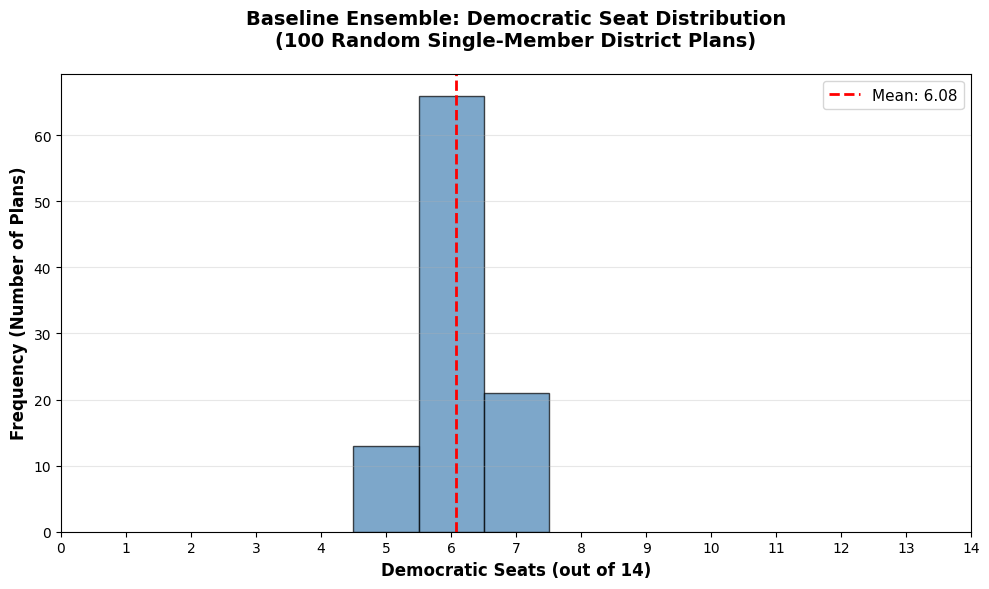

In [16]:
plot_baseline_histogram(ensemble_csv_path, output_dir)

## <span style="color:red"> Streamlit Run Command </span>
#### This line will run continually from streamlit start until streamlit end. Be sure to stop the execution of this line when you want to stop streaming the dashboard. After wards the next and final cell should run, which clears the <code>outputs</code> directory. If the directory doesn't get removed, delete it yourself to ensure a clean environment for 

In [ ]:
!streamlit run "../Client/baseline_dashboard.py"


  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://192.0.0.2:8501

  For better performance, install the Watchdog module:

  $ xcode-select --install
  $ pip install watchdog
            


#### Removes <code>outputs</code> directory for cleanup

In [ ]:
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)